# NYC Job Postings: Career Level, Salary, and Industry
### Data Science Semester Project — Replication Code

**Research Question:** Is there a relationship between career level and salary range within NYC job postings, and does this relationship vary across industries?

**Design:** Observational — we analyze existing NYC job posting data without manipulation.

**Data Source:** NYC Job Postings dataset from Data.gov

---
## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import spearmanr, kruskal
import warnings
warnings.filterwarnings('ignore')

# Style settings
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')

PALETTE = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
           '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [3]:
# ── Load Data ──────────────────────────────────────────────────────────
df_raw = pd.read_csv('Jobs_NYC_Postings.csv')
print(f'Raw dataset shape: {df_raw.shape}')
print(f'Columns: {list(df_raw.columns)}')

Raw dataset shape: (2371, 30)
Columns: ['Job ID', 'Agency', 'Posting Type', '# Of Positions', 'Business Title', 'Civil Service Title', 'Title Classification', 'Title Code No', 'Level', 'Job Category', 'Full-Time/Part-Time indicator', 'Career Level', 'Salary Range From', 'Salary Range To', 'Salary Frequency', 'Work Location', 'Division/Work Unit', 'Job Description', 'Minimum Qual Requirements', 'Preferred Skills', 'Additional Information', 'To Apply', 'Hours/Shift', 'Work Location 1', 'Recruitment Contact', 'Residency Requirement', 'Posting Date', 'Post Until', 'Posting Updated', 'Process Date']


---
## 2. Data Cleaning & Feature Engineering

In [4]:
# ── Filter to Annual Salary Postings Only ─────────────────────────────
df = df_raw[df_raw['Salary Frequency'] == 'Annual'].copy()

# Create salary midpoint as the central estimate of the pay range
df['Salary Mid'] = (df['Salary Range From'] + df['Salary Range To']) / 2

# Remove implausible salaries (placeholder zeros, extreme outliers)
df = df[(df['Salary Mid'] > 10_000) & (df['Salary Mid'] < 400_000)]

# ── Define and Encode Career Level Order ──────────────────────────────
# We assign an ordinal number to each career level so we can compute correlations
CAREER_ORDER = ['Student', 'Entry-Level', 'Experienced (non-manager)', 'Manager', 'Executive']
level_map = {level: i for i, level in enumerate(CAREER_ORDER)}

df = df[df['Career Level'].isin(CAREER_ORDER)].copy()
df['Career Level Num'] = df['Career Level'].map(level_map)
df['Career Level'] = pd.Categorical(df['Career Level'], categories=CAREER_ORDER, ordered=True)

# ── Simplify Industry Categories ──────────────────────────────────────
def simplify_category(cat):
    """Map verbose NYC job categories to cleaner industry groups."""
    if not isinstance(cat, str):
        return 'Other'
    cat_lower = cat.lower()
    if 'technology' in cat_lower or ('data' in cat_lower and 'innovation' in cat_lower):
        return 'Technology & Data'
    elif 'health' in cat_lower or 'mental' in cat_lower:
        return 'Health'
    elif 'legal' in cat_lower:
        return 'Legal'
    elif 'finance' in cat_lower or 'accounting' in cat_lower:
        return 'Finance & Accounting'
    elif 'engineering' in cat_lower or 'architecture' in cat_lower or 'planning' in cat_lower:
        return 'Engineering & Planning'
    elif 'social service' in cat_lower:
        return 'Social Services'
    elif 'public safety' in cat_lower or 'inspection' in cat_lower:
        return 'Public Safety'
    elif 'administration' in cat_lower or 'human resources' in cat_lower:
        return 'Admin & HR'
    elif 'policy' in cat_lower or 'research' in cat_lower:
        return 'Policy & Research'
    elif 'communications' in cat_lower:
        return 'Communications'
    elif 'constituent' in cat_lower or 'community' in cat_lower:
        return 'Community Services'
    elif 'building' in cat_lower or 'maintenance' in cat_lower:
        return 'Building & Maintenance'
    else:
        return 'Other'

df['Industry'] = df['Job Category'].apply(simplify_category)

print(f'Clean dataset shape: {df.shape}')
print(f'\nCareer level distribution:')
print(df['Career Level'].value_counts().sort_index())
print(f'\nIndustry distribution:')
print(df['Industry'].value_counts())

Clean dataset shape: (1957, 33)

Career level distribution:
Career Level
Student                         0
Entry-Level                   264
Experienced (non-manager)    1448
Manager                       221
Executive                      24
Name: count, dtype: int64

Industry distribution:
Industry
Engineering & Planning    403
Health                    305
Legal                     277
Community Services        164
Technology & Data         147
Finance & Accounting      147
Social Services           143
Public Safety             109
Admin & HR                104
Building & Maintenance     89
Policy & Research          67
Other                       2
Name: count, dtype: int64


---
## 3. Overall Analysis: Career Level vs. Salary

First, let's establish the overall relationship before breaking it down by industry.

In [5]:
# ── Summary Statistics by Career Level ───────────────────────────────
summary = df.groupby('Career Level', observed=True)['Salary Mid'].agg(
    Count='count',
    Mean='mean',
    Median='median',
    Std='std',
    Q25=lambda x: x.quantile(0.25),
    Q75=lambda x: x.quantile(0.75)
).round(0)

print('=== Salary Summary by Career Level (Annual, USD) ===')
print(summary.to_string())

=== Salary Summary by Career Level (Annual, USD) ===
                           Count      Mean    Median      Std       Q25       Q75
Career Level                                                                     
Entry-Level                  264   58753.0   56023.0  13064.0   47886.0   66050.0
Experienced (non-manager)   1448   86615.0   82929.0  24324.0   68090.0  101187.0
Manager                      221  137254.0  132496.0  30030.0  114326.0  153508.0
Executive                     24  194859.0  188684.0  35690.0  171669.0  219625.0


In [6]:
# ── Spearman Correlation (Overall) ────────────────────────────────────
# We use Spearman because Career Level is ordinal (ranked) not continuous
rho, pval = spearmanr(df['Career Level Num'], df['Salary Mid'])

print('=== Overall Spearman Correlation: Career Level vs. Salary Midpoint ===')
print(f'  Spearman rho  = {rho:.4f}')
print(f'  p-value       = {pval:.2e}')
print(f'  N             = {len(df)}')
print()
if pval < 0.05:
    print('  → Result is statistically significant at the 0.05 level.')
    print(f'  → A rho of {rho:.2f} indicates a strong positive monotonic relationship.')

=== Overall Spearman Correlation: Career Level vs. Salary Midpoint ===
  Spearman rho  = 0.6184
  p-value       = 7.88e-207
  N             = 1957

  → Result is statistically significant at the 0.05 level.
  → A rho of 0.62 indicates a strong positive monotonic relationship.


---
## Figure 1: Salary Distribution by Career Level (Box Plot)

This is our primary figure — it shows how salary midpoints distribute across the five career levels.

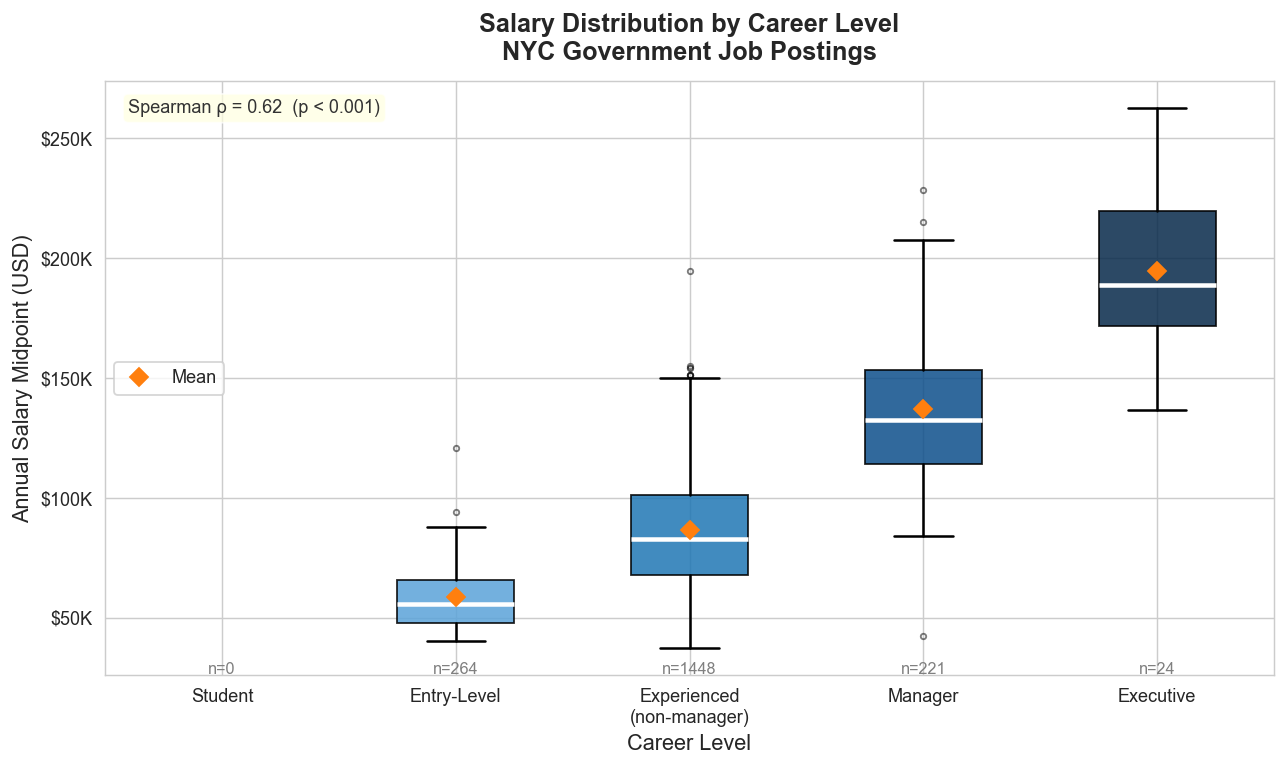

Figure 1 saved.


In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

# Color palette from low to high level
level_colors = ['#a8c8f0', '#5ba3d9', '#1f77b4', '#0d4f8b', '#07294a']

# Only plot career levels with data
plot_levels = [l for l in CAREER_ORDER if l in df['Career Level'].cat.categories]
plot_data   = [df[df['Career Level'] == l]['Salary Mid'].values for l in plot_levels]

bp = ax.boxplot(
    plot_data,
    labels=[l.replace(' (non-manager)', '\n(non-manager)') for l in plot_levels],
    patch_artist=True,
    medianprops=dict(color='white', linewidth=2.5),
    whiskerprops=dict(linewidth=1.4),
    capprops=dict(linewidth=1.4),
    flierprops=dict(marker='o', alpha=0.3, markersize=3)
)

for patch, color in zip(bp['boxes'], level_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

# Add mean markers
means = [np.mean(d) for d in plot_data]
for i, mean in enumerate(means, 1):
    ax.plot(i, mean, 'D', color='#ff7f0e', markersize=7, zorder=5, label='Mean' if i == 1 else '')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.set_title('Salary Distribution by Career Level\nNYC Government Job Postings', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Career Level', fontsize=12)
ax.set_ylabel('Annual Salary Midpoint (USD)', fontsize=12)
ax.legend(fontsize=10)

# Annotate with sample sizes
for i, (level, data) in enumerate(zip(plot_levels, plot_data), 1):
    ax.text(i, ax.get_ylim()[0] * 0.98, f'n={len(data)}',
            ha='center', va='bottom', fontsize=9, color='gray')

# Add rho annotation
ax.text(0.02, 0.97, f'Spearman ρ = {rho:.2f}  (p < 0.001)',
        transform=ax.transAxes, fontsize=10,
        verticalalignment='top', color='#333333',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.7))

plt.tight_layout()
plt.savefig('fig1_salary_by_career_level.png', bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

---
## Figure 2: Spearman Correlation by Industry

This is the key comparison — how strong is the career level → salary relationship *within* each industry? A higher bar means career level is a better predictor of pay in that sector.

In [8]:
# ── Compute Spearman rho per industry ────────────────────────────────
# Only include industries with enough data across multiple career levels
MIN_N = 30
industry_stats = []

for industry, group in df.groupby('Industry'):
    if len(group) >= MIN_N and group['Career Level Num'].nunique() >= 3:
        rho_i, pval_i = spearmanr(group['Career Level Num'], group['Salary Mid'])
        industry_stats.append({
            'Industry': industry,
            'Spearman_rho': rho_i,
            'p_value': pval_i,
            'N': len(group),
            'significant': pval_i < 0.05
        })

ind_df = pd.DataFrame(industry_stats).sort_values('Spearman_rho', ascending=False)

print('=== Spearman rho by Industry (Career Level vs. Salary) ===')
print(ind_df[['Industry','Spearman_rho','p_value','N','significant']].to_string(index=False))

=== Spearman rho by Industry (Career Level vs. Salary) ===
              Industry  Spearman_rho      p_value   N  significant
Engineering & Planning      0.747277 3.544414e-73 403         True
    Community Services      0.740866 8.358813e-30 164         True
                 Legal      0.702872 1.414578e-42 277         True
            Admin & HR      0.649719 8.540333e-14 104         True
Building & Maintenance      0.622146 7.623018e-11  89         True
  Finance & Accounting      0.620982 4.837176e-17 147         True
       Social Services      0.513816 5.275515e-11 143         True
                Health      0.507664 2.197947e-21 305         True
     Policy & Research      0.498816 1.737081e-05  67         True
     Technology & Data      0.438423 2.792147e-08 147         True
         Public Safety      0.342457 2.673978e-04 109         True


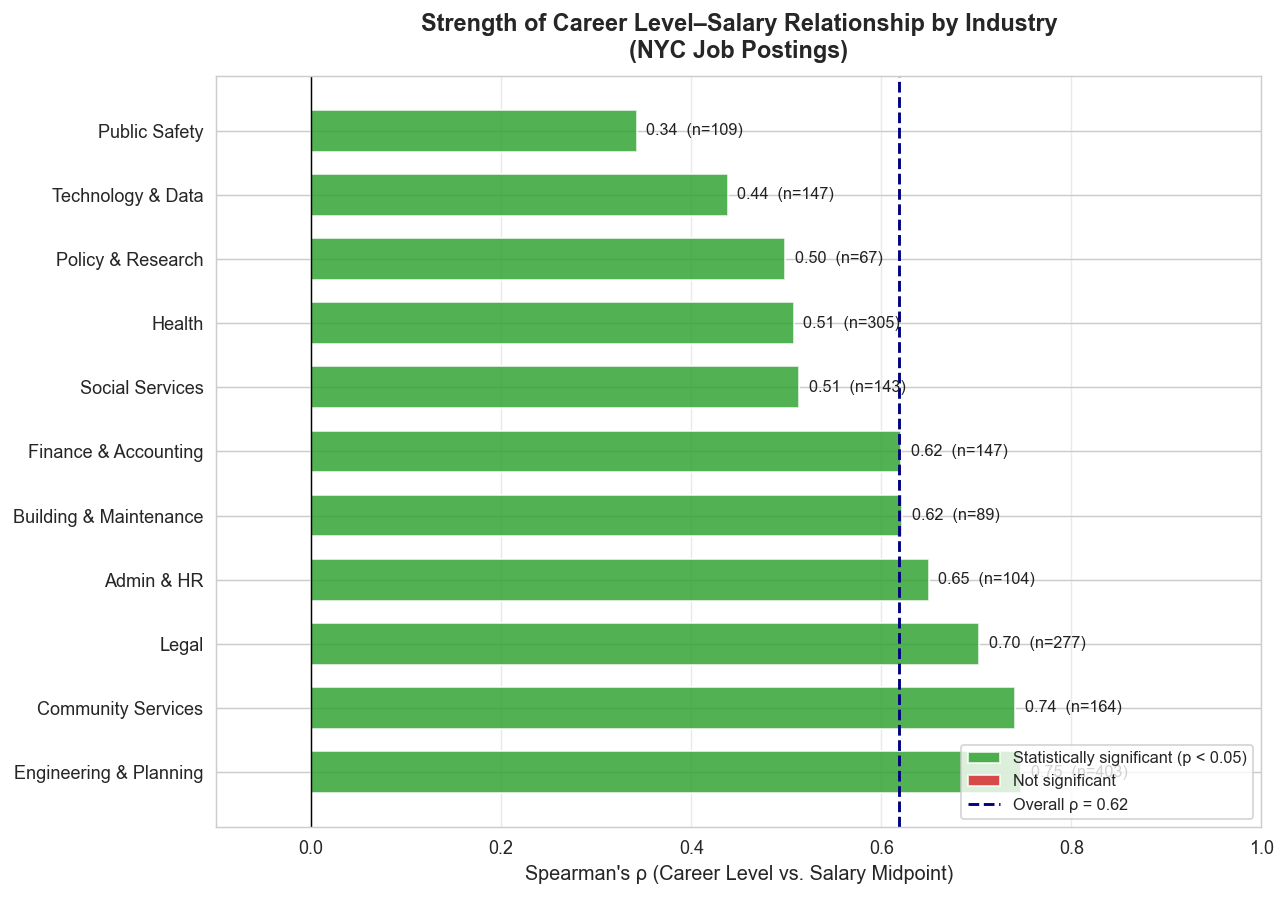

Figure 2 saved.


In [9]:
fig, ax = plt.subplots(figsize=(10, 7))

colors = ['#2ca02c' if s else '#d62728' for s in ind_df['significant']]

bars = ax.barh(
    ind_df['Industry'],
    ind_df['Spearman_rho'],
    color=colors,
    alpha=0.82,
    edgecolor='white',
    height=0.65
)

# Add rho values on bars
for bar, rho_val, n in zip(bars, ind_df['Spearman_rho'], ind_df['N']):
    offset = 0.01 if rho_val >= 0 else -0.01
    ax.text(rho_val + offset, bar.get_y() + bar.get_height()/2,
            f'{rho_val:.2f}  (n={n})',
            va='center', ha='left' if rho_val >= 0 else 'right',
            fontsize=9, color='#222')

# Overall reference line
ax.axvline(rho, color='navy', linewidth=1.6, linestyle='--', label=f'Overall ρ = {rho:.2f}')
ax.axvline(0, color='black', linewidth=0.8)

# Legend patches
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ca02c', alpha=0.82, label='Statistically significant (p < 0.05)'),
    Patch(facecolor='#d62728', alpha=0.82, label='Not significant'),
    plt.Line2D([0], [0], color='navy', linewidth=1.6, linestyle='--', label=f'Overall ρ = {rho:.2f}')
]
ax.legend(handles=legend_elements, fontsize=9, loc='lower right')

ax.set_xlabel("Spearman's ρ (Career Level vs. Salary Midpoint)", fontsize=11)
ax.set_title('Strength of Career Level–Salary Relationship by Industry\n(NYC Job Postings)', fontsize=13, fontweight='bold', pad=10)
ax.set_xlim(-0.1, 1.0)
ax.grid(axis='x', alpha=0.4)

plt.tight_layout()
plt.savefig('fig2_spearman_by_industry.png', bbox_inches='tight')
plt.show()
print('Figure 2 saved.')

---
## Figure 3: Mean Salary Heatmap — Career Level × Industry

A heatmap lets us see the salary landscape at a glance: where are the highest-paying combinations of career level and industry?

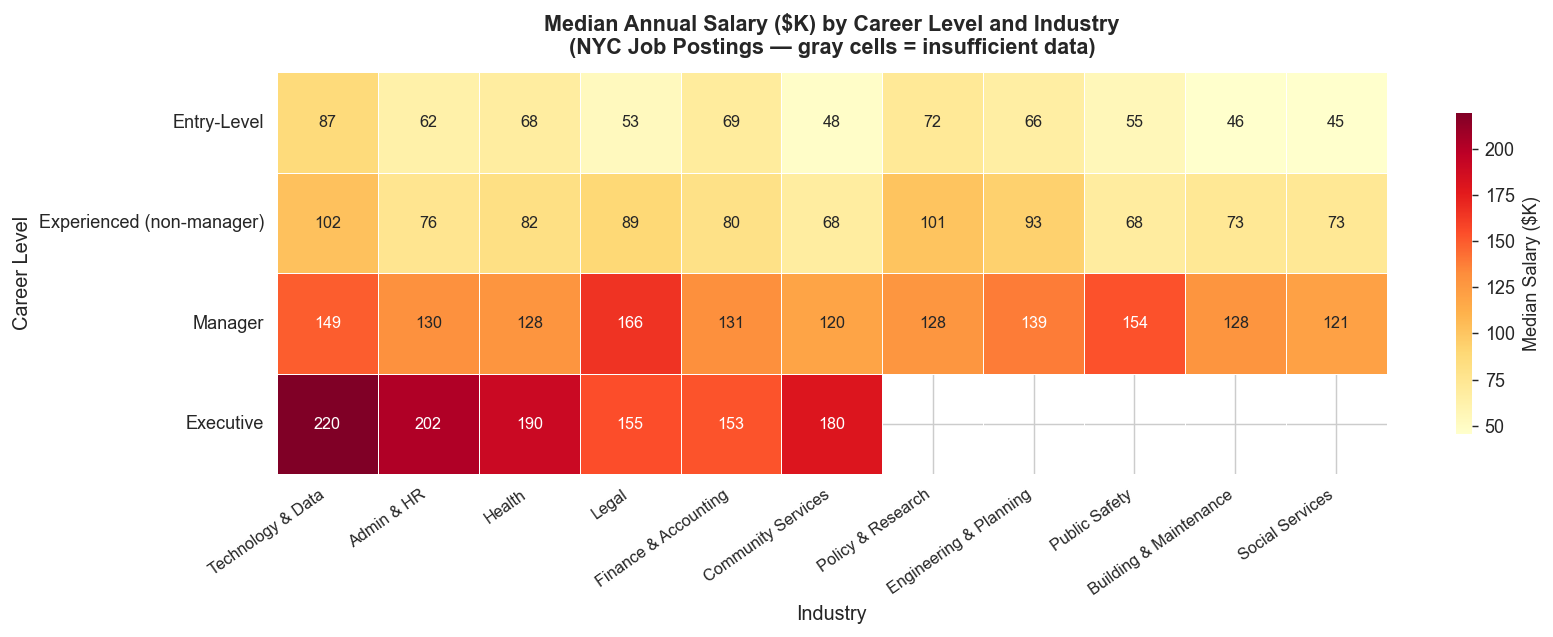

Figure 3 saved.


In [10]:
# Select industries with sufficient data
top_industries = ind_df['Industry'].tolist()  # only those that passed MIN_N filter
df_heatmap = df[df['Industry'].isin(top_industries)].copy()

# Only keep career levels with enough data overall
heat_levels = [l for l in CAREER_ORDER if l != 'Student']  # Student salaries are low/stipends
df_heatmap = df_heatmap[df_heatmap['Career Level'].isin(heat_levels)]

pivot = df_heatmap.pivot_table(
    values='Salary Mid',
    index='Career Level',
    columns='Industry',
    aggfunc='median'
)

# Sort columns by average median salary (highest right)
col_order = pivot.mean(axis=0).sort_values(ascending=False).index
pivot = pivot[col_order]
pivot.index = pd.CategoricalIndex(pivot.index, categories=heat_levels, ordered=True)
pivot = pivot.sort_index()

fig, ax = plt.subplots(figsize=(13, 5))

sns.heatmap(
    pivot / 1000,  # convert to $K
    annot=True,
    fmt='.0f',
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Median Salary ($K)', 'shrink': 0.8},
    annot_kws={'size': 9}
)

ax.set_title('Median Annual Salary ($K) by Career Level and Industry\n(NYC Job Postings — gray cells = insufficient data)',
             fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel('Industry', fontsize=11)
ax.set_ylabel('Career Level', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig('fig3_heatmap_salary_level_industry.png', bbox_inches='tight')
plt.show()
print('Figure 3 saved.')

---
## Figure 4: Salary Gap — Entry-Level vs. Manager, by Industry

Rather than just showing correlation strength, this figure makes the *economic stakes* concrete: how many more dollars does a Manager earn vs. an Entry-Level hire in each industry?

In [11]:
# ── Compute Entry-Level vs. Manager salary gap by industry ────────────
gap_rows = []
for industry in top_industries:
    entry = df[(df['Industry'] == industry) & (df['Career Level'] == 'Entry-Level')]['Salary Mid']
    mgr   = df[(df['Industry'] == industry) & (df['Career Level'] == 'Manager')]['Salary Mid']
    if len(entry) >= 5 and len(mgr) >= 5:
        gap_rows.append({
            'Industry': industry,
            'Entry_Median': entry.median(),
            'Manager_Median': mgr.median(),
            'Gap': mgr.median() - entry.median(),
            'Gap_Pct': (mgr.median() - entry.median()) / entry.median() * 100
        })

gap_df = pd.DataFrame(gap_rows).sort_values('Gap', ascending=True)

print('=== Salary Gap: Manager Median minus Entry-Level Median ===')
print(gap_df[['Industry','Entry_Median','Manager_Median','Gap','Gap_Pct']].to_string(index=False))

=== Salary Gap: Manager Median minus Entry-Level Median ===
              Industry  Entry_Median  Manager_Median       Gap    Gap_Pct
                Health       67549.0       127964.50  60415.50  89.439518
  Finance & Accounting       69045.5       130620.00  61574.50  89.179599
            Admin & HR       62500.0       130000.00  67500.00 108.000000
    Community Services       47886.0       119553.25  71667.25 149.662219
Engineering & Planning       66049.5       138525.00  72475.50 109.729067
       Social Services       45459.5       120545.00  75085.50 165.170096
         Public Safety       55265.0       153508.50  98243.50 177.768027
                 Legal       52708.5       165525.00 112816.50 214.038533


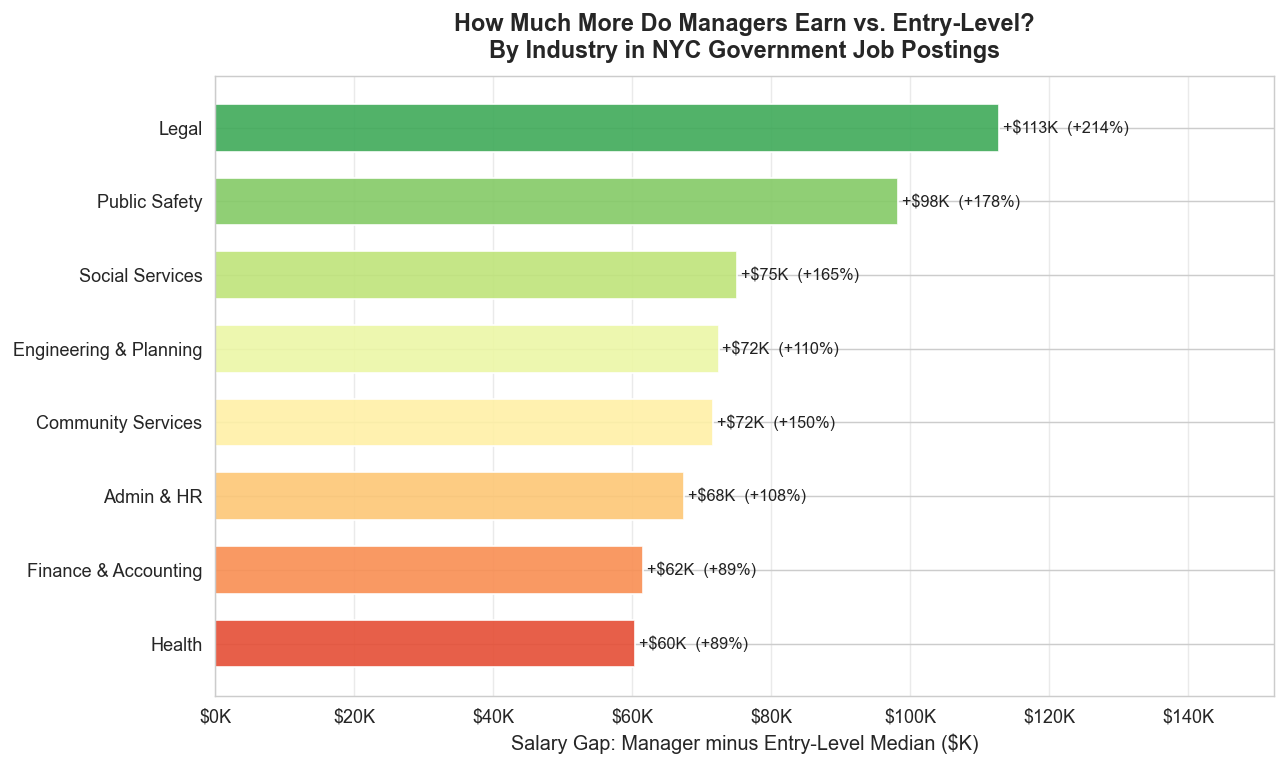

Figure 4 saved.


In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

bar_colors = plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(gap_df)))

bars = ax.barh(gap_df['Industry'], gap_df['Gap'] / 1000,
               color=bar_colors, edgecolor='white', height=0.65, alpha=0.9)

# Label each bar with dollar amount and % increase
for bar, gap, pct in zip(bars, gap_df['Gap'], gap_df['Gap_Pct']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'+${gap/1000:.0f}K  (+{pct:.0f}%)',
            va='center', fontsize=9, color='#222')

ax.set_xlabel('Salary Gap: Manager minus Entry-Level Median ($K)', fontsize=11)
ax.set_title('How Much More Do Managers Earn vs. Entry-Level?\nBy Industry in NYC Government Job Postings', fontsize=13, fontweight='bold', pad=10)
ax.set_xlim(0, gap_df['Gap'].max() / 1000 * 1.35)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}K'))
ax.grid(axis='x', alpha=0.4)

plt.tight_layout()
plt.savefig('fig4_salary_gap_entry_vs_manager.png', bbox_inches='tight')
plt.show()
print('Figure 4 saved.')

---
## 4. Supporting Statistics Mentioned in Op-Ed

In [13]:
# ── Key numbers cited in the op-ed ───────────────────────────────────

print('=== KEY STATISTICS FOR OP-ED ===')
print()

# 1. Overall dataset size
print(f'Total annual postings analyzed: {len(df):,}')
print()

# 2. Overall spearman
rho_all, p_all = spearmanr(df['Career Level Num'], df['Salary Mid'])
print(f'Overall Spearman rho: {rho_all:.3f} (p = {p_all:.2e})')
print()

# 3. Mean salaries by level
for level in CAREER_ORDER:
    subset = df[df['Career Level'] == level]['Salary Mid']
    if len(subset) > 0:
        print(f'{level}: n={len(subset)}, mean=${subset.mean():,.0f}, median=${subset.median():,.0f}')
print()

# 4. Industry-specific correlations (top & bottom)
print('Highest rho industry:', ind_df.iloc[0]['Industry'], f"rho={ind_df.iloc[0]['Spearman_rho']:.3f}")
print('Lowest rho industry: ', ind_df.iloc[-1]['Industry'], f"rho={ind_df.iloc[-1]['Spearman_rho']:.3f}")
print()

# 5. Kruskal-Wallis test: are salary distributions different across career levels?
groups = [df[df['Career Level'] == l]['Salary Mid'].values for l in CAREER_ORDER if l in df['Career Level'].values]
kw_stat, kw_p = kruskal(*groups)
print(f'Kruskal-Wallis test (salary across career levels): H={kw_stat:.2f}, p={kw_p:.2e}')
print('→ Salary distributions are statistically significantly different across career levels.')
print()

# 6. Tech vs Health comparison
for ind in ['Technology & Data', 'Health', 'Legal', 'Engineering & Planning']:
    row = ind_df[ind_df['Industry'] == ind]
    if len(row) > 0:
        print(f'{ind}: rho = {row["Spearman_rho"].values[0]:.3f}, n = {row["N"].values[0]}')

=== KEY STATISTICS FOR OP-ED ===

Total annual postings analyzed: 1,957

Overall Spearman rho: 0.618 (p = 7.88e-207)

Entry-Level: n=264, mean=$58,753, median=$56,023
Experienced (non-manager): n=1448, mean=$86,615, median=$82,929
Manager: n=221, mean=$137,254, median=$132,496
Executive: n=24, mean=$194,859, median=$188,684

Highest rho industry: Engineering & Planning rho=0.747
Lowest rho industry:  Public Safety rho=0.342

Kruskal-Wallis test (salary across career levels): H=753.48, p=5.31e-163
→ Salary distributions are statistically significantly different across career levels.

Technology & Data: rho = 0.438, n = 147
Health: rho = 0.508, n = 305
Legal: rho = 0.703, n = 277
Engineering & Planning: rho = 0.747, n = 403


---
## 5. Summary Table (Table for Op-Ed)

This table can be included as one of your figures.

In [14]:
# ── Summary table: Industry-level stats formatted for the op-ed ───────
table = ind_df[['Industry', 'Spearman_rho', 'N', 'significant']].copy()
table.columns = ['Industry', 'Spearman ρ', 'N (postings)', 'Significant?']
table['Spearman ρ'] = table['Spearman ρ'].round(3)
table['Significant?'] = table['Significant?'].map({True: 'Yes ✓', False: 'No'})
table = table.reset_index(drop=True)

print('=== Table: Spearman Correlation by Industry ===')
print(table.to_string(index=False))

=== Table: Spearman Correlation by Industry ===
              Industry  Spearman ρ  N (postings) Significant?
Engineering & Planning       0.747           403        Yes ✓
    Community Services       0.741           164        Yes ✓
                 Legal       0.703           277        Yes ✓
            Admin & HR       0.650           104        Yes ✓
Building & Maintenance       0.622            89        Yes ✓
  Finance & Accounting       0.621           147        Yes ✓
       Social Services       0.514           143        Yes ✓
                Health       0.508           305        Yes ✓
     Policy & Research       0.499            67        Yes ✓
     Technology & Data       0.438           147        Yes ✓
         Public Safety       0.342           109        Yes ✓


---
## End of Replication Code

All four figures are saved as PNG files in the working directory:
- `fig1_salary_by_career_level.png` — Box plot of salary distributions
- `fig2_spearman_by_industry.png` — Correlation strength by industry
- `fig3_heatmap_salary_level_industry.png` — Salary heatmap
- `fig4_salary_gap_entry_vs_manager.png` — Manager vs. Entry-Level salary gap

**Data source:** NYC Job Postings, Data.gov